# Global DQN Model — 300 Ausgrid Households

Trains a **single shared DQN agent** on households from all 300 datasets and evaluates it on the **same 10 cluster-representative users** as the Cluster-Local model:
- 8 **seen** (centroid-nearest users of the 8 smaller clusters, included in global training)
- 2 **holdout** (centroid-nearest users of the 2 largest clusters, held out from their cluster's training)

For every dataset the first 2/3 of timesteps are training data and the last 1/3 is the evaluation window.

## Cell 1 — Imports & device

In [87]:
import os
import sys
import copy
import json
import random
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from collections import deque
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import (
    calculate_interval_price,
    run_milp_benchmark,
    milp_total_cost,
)
from Ploting_Functions import plotMultiY

# Device selection
if T.cuda.is_available():
    device = T.device('cuda')
    print(f'NVIDIA CUDA: {T.cuda.get_device_name(0)}')
elif T.backends.mps.is_available():
    device = T.device('mps')
    print('Apple Silicon MPS')
else:
    device = T.device('cpu')
    print('CPU')

Apple Silicon MPS


## Cell 2 — Configuration

In [88]:
# ── Experiment ──────────────────────────────────────────────
SEED         = 42
N_HOLDOUT    = 5    # users withheld from training
N_EVAL_SEEN  = 5    # seen users selected for evaluation
DATA_DIR     = 'Datasorted by user'

# ── Physics (30-min step → scale rate limits accordingly) ───
BASE_STEP_MINUTES    = 15.0
DATASET_STEP_MINUTES = 30.0
step_scale           = DATASET_STEP_MINUTES / BASE_STEP_MINUTES  # = 2.0

KorakovNaDan     = int(round(1440 / DATASET_STEP_MINUTES))  # 48
BatKapaciteta    = 20.0
BatUcinkovitost  = 0.95
BatMaxPolnjenje  = 1.5 * step_scale   # 3.0 kWh/step
BatMaxPraznjenje = 1.5 * step_scale   # 3.0 kWh/step
faktorN1, faktorN2, faktorN3 = 0, 0, 1

# ── DQN hyper-parameters (best from single-user notebook) ───
fc1_dims, fc2_dims, fc3_dims, fc4_dims = 256, 128, 64, 32
lr             = 0.001
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.01
epsilon_decay  = 4e-5/4
batch_size     = 48
replace_target = KorakovNaDan * 7   # 336 steps
weight_decay   = 1e-4

# ── Training schedule ───────────────────────────────────────
N_ROUNDS           = 40*4   # outer rounds
EPISODES_PER_ROUND = 10   # users sampled per round
EPISODE_STEPS      = KorakovNaDan * 7  # 1 week per episode

print(f'KorakovNaDan={KorakovNaDan}  BatMaxPol={BatMaxPolnjenje}  BatMaxPra={BatMaxPraznjenje}')

KorakovNaDan=48  BatMaxPol=3.0  BatMaxPra=3.0


## Cell 3 — User split & cluster-aligned eval set

In [89]:
rng = np.random.default_rng(SEED)

all_ids = list(range(1, 301))
rng.shuffle(all_ids)

holdout_ids = all_ids[:N_HOLDOUT]   # 5 global holdout users (kept for reproducibility)
train_ids   = all_ids[N_HOLDOUT:]   # 295 training users

# ── Load cluster eval users (mirrors cluster_model_DQN Cell 3) ──────────────
CLUSTER_FILE  = 'clustering_results/user_ids_sorted_by_cluster_10.csv'
N_TOP_HOLDOUT = 2   # top-2 largest clusters get a held-out eval user

cluster_df = pd.read_csv(CLUSTER_FILE)
cluster_df['uid'] = cluster_df['user_id'].str.extract(r'(\d+)').astype(int)

cluster_sizes = cluster_df.groupby('cluster').size().sort_values(ascending=False)
top_clusters  = cluster_sizes.index[:N_TOP_HOLDOUT].tolist()  # e.g. [5, 1]
all_cluster_ids = sorted(cluster_df['cluster'].unique())

cluster_eval_uid = {}
for c in all_cluster_ids:
    uids = (cluster_df[cluster_df['cluster'] == c]
            .sort_values('rank_in_cluster')['uid']
            .tolist())
    cluster_eval_uid[c] = uids[0]   # centroid-nearest = most representative

# "holdout" from cluster model perspective (held out from their cluster's training)
eval_unseen = [cluster_eval_uid[c] for c in top_clusters]
# "seen" from cluster model perspective (included in their cluster's training)
eval_seen   = [cluster_eval_uid[c] for c in all_cluster_ids if c not in top_clusters]
eval_ids    = eval_seen + eval_unseen   # 8 seen + 2 holdout = 10 total

print(f'Training users  : {len(train_ids)}')
print(f'Global holdout  : {holdout_ids}  (not used for eval)')
print(f'Cluster top-2   : {top_clusters}  → holdout eval users {eval_unseen}')
print(f'Eval seen (8)   : {eval_seen}')
print(f'Eval holdout (2): {eval_unseen}')
print(f'Total eval users: {eval_ids}')

Training users  : 295
Global holdout  : [262, 294, 62, 254, 167]  (not used for eval)
Cluster top-2   : [5, 1]  → holdout eval users [66, 28]
Eval seen (8)   : [259, 31, 287, 243, 200, 251, 78, 249]
Eval holdout (2): [66, 28]
Total eval users: [259, 31, 287, 243, 200, 251, 78, 249, 66, 28]


## Cell 4 — Load & split all 300 datasets

In [90]:
def load_ausgrid(uid):
    path = os.path.join(DATA_DIR, f'Ausgrid {uid}.csv')
    df = pd.read_csv(path)
    df.index = pd.to_datetime(df['Timestamp_UTC'], format='ISO8601')
    df = df.drop(columns=['Timestamp_UTC'])
    return df

print('Loading 300 datasets...')
train_dfs = {}
test_dfs  = {}

for uid in range(1, 301):
    df = load_ausgrid(uid)
    split = int(len(df) * 2 / 3)
    train_dfs[uid] = df.iloc[:split].copy()
    test_dfs[uid]  = df.iloc[split:].copy()

sample = train_dfs[1]
print(f'Loaded. Train rows: {len(sample)}  Test rows: {len(test_dfs[1])}')
print(f'Columns: {sample.columns.tolist()}')
print(f'Date range (train user 1): {sample.index[0]} → {sample.index[-1]}')

Loading 300 datasets...
Loaded. Train rows: 35072  Test rows: 17536
Columns: ['Energy_Consumption', 'Energy_Generation', 'SMP']
Date range (train user 1): 2010-07-01 00:30:00+00:00 → 2012-06-30 16:00:00+00:00


## Cell 5 — Global normalization (no data leakage)

In [91]:
# ── 5a. SMP price normalization ─────────────────────────────
# SMP is identical across all datasets; fit once on the training portion.

def normalize_electricity_prices(data, fit=False, params=None):
    """Log + clip + RobustScaler for SMP. Identical to single-user notebook."""
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)
    log_data     = np.log1p(np.maximum(data, 0))
    log_lower    = np.log1p(max(0, lower_threshold))
    log_upper    = np.log1p(max(0, upper_threshold))
    clipped      = np.clip(log_data, log_lower, log_upper)

    if fit:
        scaler = RobustScaler()
        normalized = scaler.fit_transform(clipped)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        normalized    = params['scaler'].transform(clipped)
        fitted_params = params

    return normalized, outlier_flag, fitted_params

# Fit SMP scaler on training portion of user 1 (SMP identical for all)
smp_train_ref = train_dfs[train_ids[0]]['SMP'].values
_, _, price_norm_params = normalize_electricity_prices(smp_train_ref, fit=True)
print('SMP price scaler fitted.')

# ── 5b. Energy (Gen + Con) global scaler ────────────────────
# Concatenate ALL training portions to learn a global distribution.
shared_cols = ['Energy_Generation', 'Energy_Consumption']

print('Building global energy scaler (concatenating 295 training sets)...')
combined_energy = np.concatenate([
    train_dfs[uid][shared_cols].values.flatten()
    for uid in train_ids
]).reshape(-1, 1)

global_energy_scaler = RobustScaler()
global_energy_scaler.fit(combined_energy)
print('Energy scaler fitted.')

# ── 5c. Apply to every dataset (train + test) ───────────────
def apply_normalization(df, split_label, uid):
    """Return a fully normalised copy of df."""
    df_n = df.copy()

    # Energy columns
    for col in shared_cols:
        df_n[col] = global_energy_scaler.transform(
            df[col].values.reshape(-1, 1)
        ).flatten()

    # SMP
    smp_norm, smp_flag, _ = normalize_electricity_prices(
        df['SMP'].values, fit=False, params=price_norm_params
    )
    df_n['SMP'] = smp_norm.flatten()
    df_n['SMP_OutlierFlag'] = smp_flag.flatten()

    return df_n

print('Normalising all 300 datasets (train + test)...')
train_norm_dfs = {uid: apply_normalization(train_dfs[uid], 'train', uid) for uid in range(1, 301)}
test_norm_dfs  = {uid: apply_normalization(test_dfs[uid],  'test',  uid) for uid in range(1, 301)}

print('Done.')
print('Sample normalised train stats (user 1):')
print(train_norm_dfs[1][['Energy_Consumption', 'Energy_Generation', 'SMP']].describe().round(3))

SMP price scaler fitted.
Building global energy scaler (concatenating 295 training sets)...
Energy scaler fitted.
Normalising all 300 datasets (train + test)...
Done.
Sample normalised train stats (user 1):
       Energy_Consumption  Energy_Generation        SMP
count           35072.000          35072.000  35072.000
mean                0.673              0.515      0.368
std                 1.020              1.462      1.578
min                -0.397             -0.397     -3.552
25%                -0.017             -0.397     -0.257
50%                 0.267             -0.397      0.000
75%                 1.027              1.000      0.743
max                 8.537              5.730     12.568


## Cell 6 — Environment factory

In [92]:
def make_env(uid, split='train', episode_length=None, *,
             generate_monthly_invoice=False, generate_period_invoice=False,
             invoice_run_label=None):
    """Create a HouseholdEnvironment for the given user and data split."""
    if split == 'train':
        data   = train_dfs[uid]
        data_n = train_norm_dfs[uid]
        reset_mode = 'random'
        ep_len = episode_length if episode_length is not None else EPISODE_STEPS
    else:
        data   = test_dfs[uid]
        data_n = test_norm_dfs[uid]
        reset_mode = 'deterministic'
        ep_len = episode_length if episode_length is not None else len(data) - 1

    return HouseholdEnvironment(
        dataset          = data,
        dataset_norm     = data_n,
        observation_mode = 'sliding_window',
        reset_mode       = reset_mode,
        episode_length   = ep_len,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
        generate_monthly_invoice = generate_monthly_invoice,
        generate_period_invoice = generate_period_invoice,
        invoice_run_label = invoice_run_label,
    )

# Verify state dimension
_tmp_env = make_env(1, split='train')
STATE_DIM = int(_tmp_env.observation_space.shape[0])
print(f'State dim: {STATE_DIM}  (window_past={_tmp_env.window_past}, window_future={_tmp_env.window_future})')

State dim: 25  (window_past=0, window_future=22)


## Cell 7 — DQN agent (data-agnostic, copied from single-user notebook)

In [93]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super().__init__()
        self.layer_dims = list(layer_dims)
        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.loss = nn.SmoothL1Loss(beta=1.0)
        self.device = T.device('cuda' if T.cuda.is_available() else
                               'mps'  if T.backends.mps.is_available() else 'cpu')
        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(self, gamma, epsilon, lr, state_shape, network_dims,
                 batch_size, replace_target=336, max_mem_size=1_000_000,
                 eps_end=0.05, eps_dec=4e-5, weight_decay=1e-4, tau=0.005):
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.eps_min       = eps_end
        self.eps_dec       = eps_dec
        self.lr            = lr
        self.batch_size    = batch_size
        self.mem_size      = max_mem_size
        self.mem_cntr      = 0
        self.iter_cntr     = 0
        self.replace_target = replace_target
        self.tau           = float(tau)
        self.state_shape   = list(state_shape)
        self.network_dims  = list(network_dims)
        self.n_actions     = self.network_dims[-1]
        self.action_space  = list(range(self.n_actions))
        self.start_learning_after = int(4 * batch_size)

        self.Q_eval   = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        self.state_memory     = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory    = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory    = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory  = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        idx = self.mem_cntr % self.mem_size
        self.state_memory[idx]     = state
        self.new_state_memory[idx] = state_
        self.reward_memory[idx]    = reward
        self.action_memory[idx]    = action
        self.terminal_memory[idx]  = terminal
        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state   = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            return int(T.argmax(actions).item())
        return np.random.choice(self.action_space)

    def _soft_update_target(self):
        with T.no_grad():
            for tp, ep in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * ep.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return
        max_mem = min(self.mem_cntr, self.mem_size)
        if max_mem < self.batch_size:
            return

        batch       = np.random.choice(max_mem, self.batch_size, replace=False)
        batch_index = np.arange(self.batch_size, dtype=np.int32)

        dev = self.Q_eval.device
        s   = T.tensor(self.state_memory[batch],     dtype=T.float32, device=dev)
        s_  = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=dev)
        a   = T.tensor(self.action_memory[batch],    dtype=T.long,    device=dev)
        r   = T.tensor(self.reward_memory[batch],    dtype=T.float32, device=dev)
        t   = T.tensor(self.terminal_memory[batch],  dtype=T.float32, device=dev)

        q_eval = self.Q_eval(s)[batch_index, a]

        with T.no_grad():
            next_a  = self.Q_eval(s_).argmax(dim=1, keepdim=True)
            q_next  = self.Q_target(s_).gather(1, next_a).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - t)

        loss = self.Q_eval.loss(q_eval, q_target).to(dev)
        self.Q_eval.optimizer.zero_grad()
        loss.backward()
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)
        self.Q_eval.optimizer.step()

        self.iter_cntr += 1
        self.epsilon = max(self.epsilon - self.eps_dec, self.eps_min)

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

print(f'Network dims: [{STATE_DIM}, {fc1_dims}, {fc2_dims}, {fc3_dims}, {fc4_dims}, 5]')

Network dims: [25, 256, 128, 64, 32, 5]


## Cell 8 — Global training loop

In [94]:
import time

NETWORK_DIMS = [STATE_DIM, fc1_dims, fc2_dims, fc3_dims, fc4_dims, 5]

agent = AgentDQN(
    gamma          = gamma,
    epsilon        = epsilon_start,
    lr             = lr,
    state_shape    = [STATE_DIM],
    network_dims   = NETWORK_DIMS,
    batch_size     = batch_size,
    replace_target = replace_target,
    eps_end        = epsilon_end,
    eps_dec        = epsilon_decay,
    weight_decay   = weight_decay,
)

def train_global_dqn(agent, train_ids, n_rounds=N_ROUNDS, episodes_per_round=EPISODES_PER_ROUND):
    """
    Each round randomly samples `episodes_per_round` users from train_ids
    and runs one week-long episode per user. The agent accumulates experience
    in a single shared replay buffer across all users.
    """
    round_rewards = []

    for round_i in range(n_rounds):
        t0 = time.time()
        sampled_uids = rng.choice(train_ids, episodes_per_round, replace=True)
        round_reward = 0.0
        episodes_done = 0

        for uid in sampled_uids:
            env = make_env(uid, split='train', episode_length=EPISODE_STEPS)
            obs, _ = env.reset()
            ep_reward = 0.0

            for _ in range(EPISODE_STEPS):
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)

                agent.store_transition(obs, action, reward, next_obs, done)
                agent.learn()

                obs = next_obs
                ep_reward += reward

                if done:
                    break

            round_reward += ep_reward
            episodes_done += 1

        avg_reward = round_reward / max(episodes_done, 1)
        round_rewards.append(avg_reward)
        elapsed = time.time() - t0
        print(f'Round {round_i+1:3d}/{n_rounds}  '
              f'avg_reward={avg_reward:7.2f}  '
              f'ε={agent.epsilon:.4f}  '
              f'({elapsed:.1f}s)')

    return agent, round_rewards


print(f'Starting global training: {N_ROUNDS} rounds × {EPISODES_PER_ROUND} episodes...')
agent, training_rewards = train_global_dqn(agent, train_ids)
print(f'\nTraining complete. Final epsilon: {agent.epsilon:.4f}')

Starting global training: 160 rounds × 10 episodes...
Round   1/160  avg_reward= -30.34  ε=0.9684  (9.0s)
Round   2/160  avg_reward= -27.24  ε=0.9349  (9.3s)
Round   3/160  avg_reward= -28.99  ε=0.9014  (9.4s)
Round   4/160  avg_reward= -26.77  ε=0.8679  (9.4s)
Round   5/160  avg_reward= -27.82  ε=0.8344  (9.5s)
Round   6/160  avg_reward= -23.43  ε=0.8009  (9.7s)
Round   7/160  avg_reward= -22.84  ε=0.7674  (9.8s)
Round   8/160  avg_reward= -28.23  ε=0.7339  (9.9s)
Round   9/160  avg_reward= -24.16  ε=0.7004  (10.0s)
Round  10/160  avg_reward= -25.69  ε=0.6669  (10.1s)
Round  11/160  avg_reward= -21.40  ε=0.6334  (10.3s)
Round  12/160  avg_reward= -20.93  ε=0.5999  (10.5s)
Round  13/160  avg_reward= -18.64  ε=0.5664  (10.6s)
Round  14/160  avg_reward= -19.97  ε=0.5329  (10.8s)
Round  15/160  avg_reward= -21.82  ε=0.4994  (11.0s)
Round  16/160  avg_reward= -14.44  ε=0.4659  (11.0s)
Round  17/160  avg_reward= -13.37  ε=0.4324  (11.2s)
Round  18/160  avg_reward= -10.60  ε=0.3989  (11.3s)


### Training reward curve

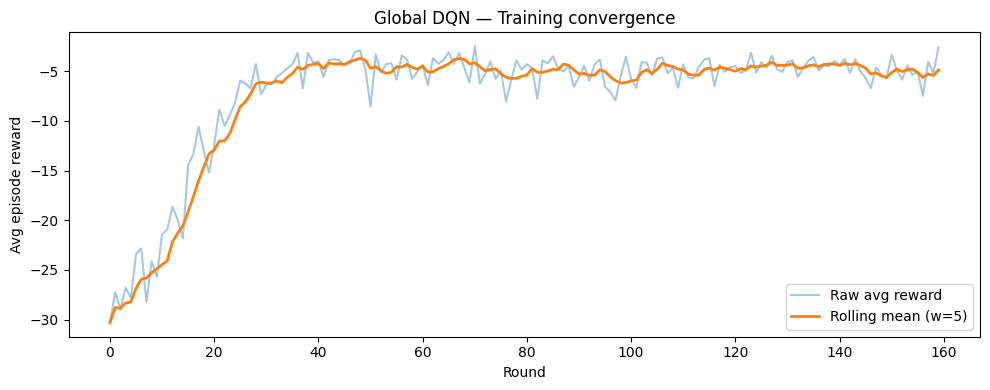

In [95]:
window = 5
trend  = pd.Series(training_rewards).rolling(window=window, min_periods=1).mean().tolist()

plt.figure(figsize=(10, 4))
plt.plot(training_rewards, alpha=0.4, label='Raw avg reward')
plt.plot(trend, linewidth=2, label=f'Rolling mean (w={window})')
plt.xlabel('Round'); plt.ylabel('Avg episode reward')
plt.title('Global DQN — Training convergence')
plt.legend(); plt.tight_layout(); plt.show()

## Cell 9 — Evaluate on 10 datasets (5 seen + 5 unseen)

In [96]:
def evaluate_user(agent, uid, verbose=False):
    """Run one full greedy episode on the test split of `uid`. Returns total cost (AUD)."""
    env = make_env(
        uid, split='test',
        generate_monthly_invoice=True, generate_period_invoice=True,
        invoice_run_label=f'dqn_eval_user{uid}',
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})

    saved_eps   = agent.epsilon
    agent.epsilon = 0.0

    last_info = {}
    steps = len(test_dfs[uid]) - 1

    for _ in range(steps):
        action = agent.choose_action(obs)
        obs, _, terminated, truncated, info = env.step(action)
        last_info = info
        if terminated or truncated:
            break

    agent.epsilon = saved_eps
    cost = float(last_info.get('cumulative_payment', 0.0))
    if verbose:
        print(f'  User {uid:3d}: {cost:.2f} AUD')
    return cost


def no_battery_baseline(uid):
    """Run the test split with bat_kapaciteta=0 and always action 4 (idle).
    Uses the identical calculate_interval_price cost logic as evaluate_user."""
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = 0,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
        generate_monthly_invoice = True,
        generate_period_invoice = True,
        invoice_run_label = f'baseline_no_battery_user{uid}',
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})
    last_info = {}
    for _ in range(len(test_dfs[uid]) - 1):
        obs, _, terminated, truncated, last_info = env.step(4)  # 4 = idle, no battery
        if terminated or truncated:
            break
    return float(last_info.get('cumulative_payment', 0.0))


print('Evaluating global DQN on 10 datasets...')
results = []

for uid in eval_seen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'seen', 'cost_aud': cost, 'baseline_aud': baseline})

for uid in eval_unseen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'unseen', 'cost_aud': cost, 'baseline_aud': baseline})

df_results = pd.DataFrame(results)
df_results['improvement_%'] = (
    (df_results['baseline_aud'] - df_results['cost_aud']) / df_results['baseline_aud'].abs() * 100
).round(1)

print('\n── Results ────────────────────────────────────────────')
print(df_results.to_string(index=False))

Evaluating global DQN on 10 datasets...
  User 259: 899.62 AUD
  User  31: 1081.38 AUD
  User 287: 1262.99 AUD
  User 243: 1243.01 AUD
  User 200: 1631.84 AUD
  User 251: 1370.21 AUD
  User  78: 1111.42 AUD
  User 249: 1385.00 AUD
  User  66: 930.06 AUD
  User  28: 1000.93 AUD

── Results ────────────────────────────────────────────
 uid  group    cost_aud  baseline_aud  improvement_%
 259   seen  899.615076    945.470392            4.9
  31   seen 1081.379540   1188.034150            9.0
 287   seen 1262.994362   1387.038645            8.9
 243   seen 1243.008314   1413.236405           12.0
 200   seen 1631.843624   1650.528571            1.1
 251   seen 1370.207630   1505.738345            9.0
  78   seen 1111.421638   1240.861345           10.4
 249   seen 1384.996062   1633.205087           15.2
  66 unseen  930.062251   1000.186961            7.0
  28 unseen 1000.929634   1093.043263            8.4


In [ ]:
def run_milp_for_user(
    uid, verbose=False, *,
    generate_invoice=False, invoice_output_dir=None, invoice_run_label="milp_eval",
):
    """
    Perfect-foresight MILP benchmark on the test split of `uid`.

    Thin wrapper: the formulation lives in Basic_Functions.run_milp_benchmark,
    shared with smart_home_nanogrid_DQN / cluster_model_DQN / sweep_analysis.
    Returns total cost (AUD) - the theoretical optimum.

    With generate_invoice=True the shared benchmark also emits monthly and
    whole-period line-item invoices for the solved trajectory, built off the
    same re-priced intervals that produce the returned cost.
    """
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

    total_cost = milp_total_cost(
        env,
        problem_name=f'Microgrid_User{uid}',
        generate_invoice=generate_invoice,
        invoice_output_dir=invoice_output_dir,
        invoice_run_label=invoice_run_label,
    )
    if verbose:
        print(f'  User {uid:3d} MILP: {total_cost:.2f} AUD')
    return total_cost


# Run MILP for all 10 eval users (this takes a few minutes per user)
print('Running MILP benchmark for 10 eval datasets (continuous relaxation)...')
milp_costs = {}
for uid in eval_ids:
    milp_costs[uid] = run_milp_for_user(
        uid, verbose=True,
        generate_invoice=True, invoice_run_label=f'milp_eval_user{uid}',
    )

# Merge MILP costs into df_results
df_results['milp_aud'] = df_results['uid'].map(milp_costs)

# Compute all comparison metrics
df_results['imp_dqn_%']         = ((df_results['baseline_aud'] - df_results['cost_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['imp_milp_%']        = ((df_results['baseline_aud'] - df_results['milp_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['gap_dqn_vs_milp_%'] = ((df_results['cost_aud']     - df_results['milp_aud'])  / df_results['milp_aud']     * 100).round(1)
df_results['fraction_theor_%']  = ((df_results['baseline_aud'] - df_results['cost_aud'])  / (df_results['baseline_aud'] - df_results['milp_aud']) * 100).round(1)

print('\nDone.')

# Cell 10: Resoults and visualization

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PER-USER RESULTS
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 User  Group  No-battery (AUD)   DQN (AUD)  MILP optimum (AUD)  DQN impr. vs base (%)  MILP impr. vs base (%)  DQN gap vs MILP (%)  DQN fraction of theor. gain (%)
  259   seen        945.470392  899.615076          781.413822                    4.9                    17.4                 15.1                             28.0
   31   seen       1188.034150 1081.379540          887.487108                    9.0                    25.3                 21.8                             35.5
  287   seen       1387.038645 1262.994362         1021.050642                    8.9                    26.4                 23.7                             33.9
  243   seen       1413.236405 1243.008314          985.594581                   12.0

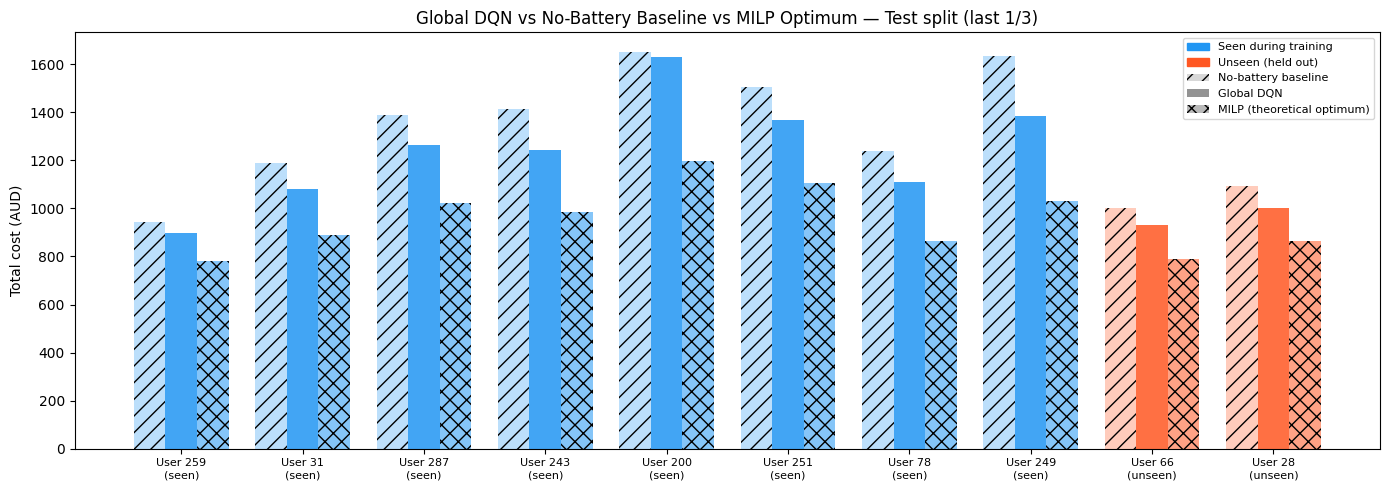

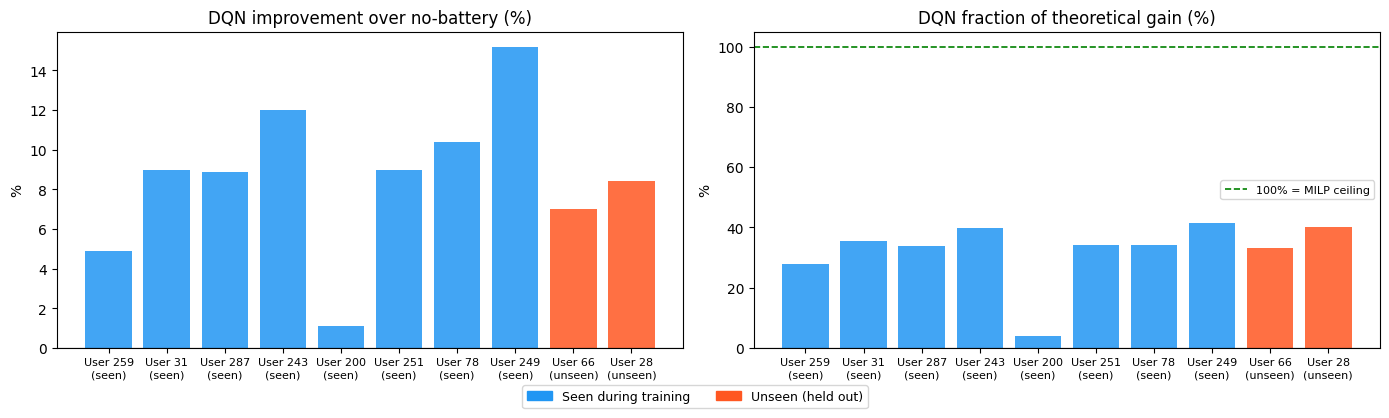

Plots saved: global_dqn_costs.png, global_dqn_improvement.png


In [98]:
# ── Per-user results table ───────────────────────────────────
display_cols = {
    'uid':               'User',
    'group':             'Group',
    'baseline_aud':      'No-battery (AUD)',
    'cost_aud':          'DQN (AUD)',
    'milp_aud':          'MILP optimum (AUD)',
    'imp_dqn_%':         'DQN impr. vs base (%)',
    'imp_milp_%':        'MILP impr. vs base (%)',
    'gap_dqn_vs_milp_%': 'DQN gap vs MILP (%)',
    'fraction_theor_%':  'DQN fraction of theor. gain (%)',
}
df_display = df_results[list(display_cols.keys())].rename(columns=display_cols)
print('═' * 120)
print('PER-USER RESULTS')
print('═' * 120)
print(df_display.to_string(index=False))

# ── Group averages ───────────────────────────────────────────
print('\n' + '═' * 80)
print('GROUP AVERAGES')
print('═' * 80)
group_avg = df_results.groupby('group').agg(
    N               = ('uid',               'count'),
    Baseline_AUD    = ('baseline_aud',      'mean'),
    DQN_AUD         = ('cost_aud',          'mean'),
    MILP_AUD        = ('milp_aud',          'mean'),
    DQN_impr_pct    = ('imp_dqn_%',         'mean'),
    MILP_impr_pct   = ('imp_milp_%',        'mean'),
    Gap_MILP_pct    = ('gap_dqn_vs_milp_%', 'mean'),
    Frac_theor_pct  = ('fraction_theor_%',  'mean'),
).round(2)
group_avg.columns = [
    'N', 'Baseline (AUD)', 'DQN (AUD)', 'MILP (AUD)',
    'DQN impr.%', 'MILP impr.%', 'DQN gap vs MILP%', 'Frac. of theor. gain%'
]
print(group_avg.to_string())

# ── Bar chart: absolute costs ────────────────────────────────
x          = np.arange(len(df_results))
width      = 0.26
colors     = {'seen': '#2196F3', 'unseen': '#FF5722'}
bar_colors = [colors[g] for g in df_results['group']]
xlabels    = [f'User {r.uid}\n({r.group})' for r in df_results.itertuples()]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, df_results['baseline_aud'], width, color=bar_colors, alpha=0.30, hatch='//')
ax.bar(x,         df_results['cost_aud'],     width, color=bar_colors, alpha=0.85)
ax.bar(x + width, df_results['milp_aud'],     width, color=bar_colors, alpha=0.55, hatch='xx')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Total cost (AUD)')
ax.set_title('Global DQN vs No-Battery Baseline vs MILP Optimum — Test split (last 1/3)')
ax.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
    mpatches.Patch(facecolor='grey', alpha=0.30, hatch='//', label='No-battery baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.85,             label='Global DQN'),
    mpatches.Patch(facecolor='grey', alpha=0.55, hatch='xx', label='MILP (theoretical optimum)'),
], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('global_dqn_costs.png', dpi=150)
plt.show()

# ── Two-panel improvement chart ──────────────────────────────
fig2, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

ax_left.bar(x, df_results['imp_dqn_%'], color=bar_colors, alpha=0.85)
ax_left.axhline(0, color='black', linewidth=0.8)
ax_left.set_xticks(x); ax_left.set_xticklabels(xlabels, fontsize=8)
ax_left.set_ylabel('%'); ax_left.set_title('DQN improvement over no-battery (%)')

ax_right.bar(x, df_results['fraction_theor_%'], color=bar_colors, alpha=0.85)
ax_right.axhline(0,   color='black', linewidth=0.8)
ax_right.axhline(100, color='green', linewidth=1.2, linestyle='--', label='100% = MILP ceiling')
ax_right.set_xticks(x); ax_right.set_xticklabels(xlabels, fontsize=8)
ax_right.set_ylabel('%'); ax_right.set_title('DQN fraction of theoretical gain (%)')
ax_right.legend(fontsize=8)

fig2.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.savefig('global_dqn_improvement.png', dpi=150)
plt.show()

print('Plots saved: global_dqn_costs.png, global_dqn_improvement.png')